### Imports

In [1]:
import json
import warnings
from pathlib import Path

import torch
from matplotlib import pyplot as plt

from src.datasets.audio_dataset import AudioDataset
from src.datasets.spike_dataset import SpikeDataset
from src.engine import benchmark_snn, get_split_dataloaders
from src.models.snn import SNN
from src.models.snn_encoded import SNNEncoded
from src.preprocessing import get_snn_pipeline
from src.utils import plot_accuracy_comparison, plot_energy_comparison

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
DIRECT_NAME: str = SNN.NAME
INPUT_DIR = Path('../../data/audio-mnist')
DIRECT_MODEL_PATH = Path(f'../../models/{DIRECT_NAME}.pth')
DIRECT_HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{DIRECT_NAME}.json')

ENCODED_NAME: str = SNNEncoded.NAME
ENCODED_INPUT_DIR = Path('../../processed/audio-mnist')
ENCODED_MODEL_PATH = Path(f'../../models/{ENCODED_NAME}.pth')
ENCODED_HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{ENCODED_NAME}.json')

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Comparison

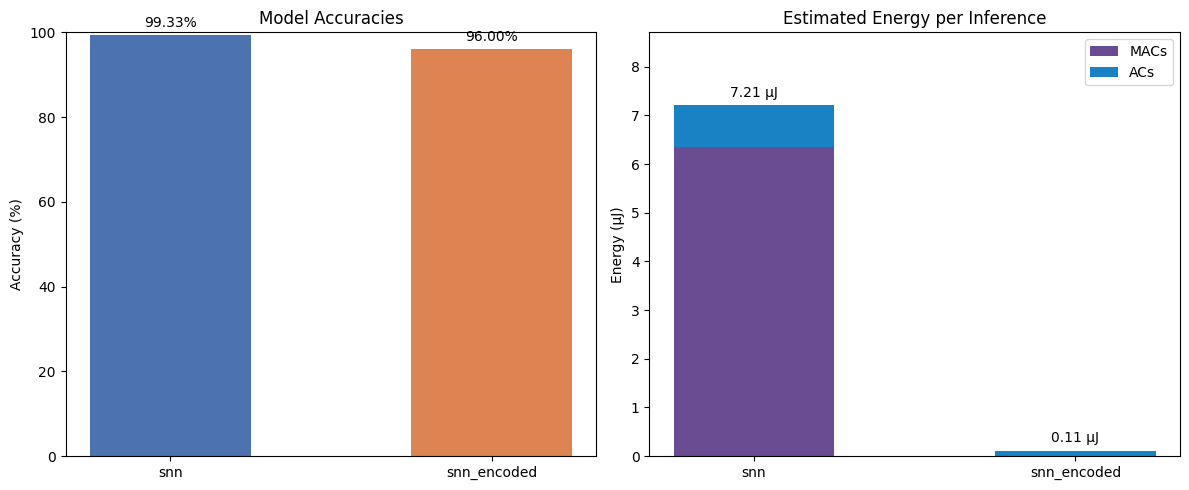

In [4]:
if __name__ == '__main__':
    direct_dataset = AudioDataset(INPUT_DIR, get_snn_pipeline())
    encoded_dataset = SpikeDataset(ENCODED_INPUT_DIR)

    # Use the same seed for split so that models are tested on exact same things
    _, _, direct_test_dataloader = get_split_dataloaders(direct_dataset)
    _, _, encoded_test_dataloader = get_split_dataloaders(encoded_dataset)

    _, sample_direct_labels = next(iter(direct_test_dataloader))
    _, sample_encoded_labels = next(iter(encoded_test_dataloader))
    assert torch.equal(sample_direct_labels, sample_encoded_labels) # Should fail here immediately, otherwise not a fair test

    # Load 2D Direct SNN
    direct_hyperparameters = json.load(open(DIRECT_HYPERPARAMETERS_PATH, 'r'))[1]['params']
    direct_snn = SNN(
        beta_init=direct_hyperparameters['beta_init'],
        slope=direct_hyperparameters['slope'],
        timesteps=direct_hyperparameters['timesteps']
    ).to(device)
    direct_snn.load_state_dict(torch.load(DIRECT_MODEL_PATH))

    # Load 1D Encoded SNN
    encoded_hyperparameters = json.load(open(ENCODED_HYPERPARAMETERS_PATH, 'r'))
    encoded_snn = SNNEncoded(
        beta_init=encoded_hyperparameters['beta_init'],
        slope=encoded_hyperparameters['slope']
    ).to(device)
    encoded_snn.load_state_dict(torch.load(ENCODED_MODEL_PATH))

    direct_acc, direct_acs, direct_macs = benchmark_snn(device, direct_snn, direct_test_dataloader, direct_encoded=True, leave=False)
    encoded_acc, encoded_acs, encoded_macs = benchmark_snn(device, encoded_snn, encoded_test_dataloader, leave=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    plot_accuracy_comparison(ax1, DIRECT_NAME, direct_acc, ENCODED_NAME, encoded_acc)
    plot_energy_comparison(ax2, DIRECT_NAME, direct_macs, direct_acs, ENCODED_NAME, encoded_macs, encoded_acs)
    plt.tight_layout()
    plt.show()